<a href="https://colab.research.google.com/github/shuyaguan/musa-650-spring-2025/blob/HW4/Shuya_Guan_DL_HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Data Loading, Processing, and Exploration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import random
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import itertools
from google.colab import drive

drive.mount('/content/drive')

!wget -q https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip

!ls -la
!ls -la EuroSAT_RGB/

Mounted at /content/drive
total 92468
drwxr-xr-x  1 root root     4096 Apr  9 18:54 .
drwxr-xr-x  1 root root     4096 Apr  9 18:53 ..
drwxr-xr-x  4 root root     4096 Apr  8 13:37 .config
drwx------  6 root root     4096 Apr  9 18:54 drive
drwxr-xr-x 12 root root     4096 Mar  9  2023 EuroSAT_RGB
-rw-r--r--  1 root root 94658721 Apr  9 18:54 EuroSAT_RGB.zip
drwxr-xr-x  1 root root     4096 Apr  8 13:37 sample_data
total 1128
drwxr-xr-x 12 root root   4096 Mar  9  2023 .
drwxr-xr-x  1 root root   4096 Apr  9 18:54 ..
drwxr-xr-x  2 root root 135168 Sep 18  2018 AnnualCrop
drwxr-xr-x  2 root root 114688 Sep 18  2018 Forest
drwxr-xr-x  2 root root 167936 Sep 18  2018 HerbaceousVegetation
drwxr-xr-x  2 root root  81920 Sep 18  2018 Highway
drwxr-xr-x  2 root root 110592 Sep 18  2018 Industrial
drwxr-xr-x  2 root root  69632 Sep 18  2018 Pasture
drwxr-xr-x  2 root root 118784 Sep 18  2018 PermanentCrop
drwxr-xr-x  2 root root 135168 Sep 18  2018 Residential
drwxr-xr-x  2 root root  94208 Se

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

data_dir = 'EuroSAT_RGB'
class_names = sorted(os.listdir(data_dir))
print("Classes:", class_names)
label_to_idx = {label: idx for idx, label in enumerate(class_names)}
print("Label to index mapping:", label_to_idx)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Label to index mapping: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [ ]:
def load_images(data_dir, img_size=(64, 64)):
    images = []
    labels = []
    gray_images = []

    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        class_idx = label_to_idx[class_name]

        print(f"Loading {class_name} images...")
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)

            # Read RGB image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)

            # Create grayscale image
            gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

            # Normalize
            img = img / 255.0
            gray_img = gray_img / 255.0

            images.append(img)
            gray_images.append(gray_img)
            labels.append(class_idx)

    return np.array(images), np.array(gray_images), np.array(labels)

print("Loading images...")
images, gray_images, labels = load_images(data_dir)
print(f"Loaded {len(images)} images")

Loading images...
Loading AnnualCrop images...
Loading Forest images...
Loading HerbaceousVegetation images...
Loading Highway images...
Loading Industrial images...
Loading Pasture images...
Loading PermanentCrop images...
Loading Residential images...
Loading River images...
Loading SeaLake images...
Loaded 27000 images


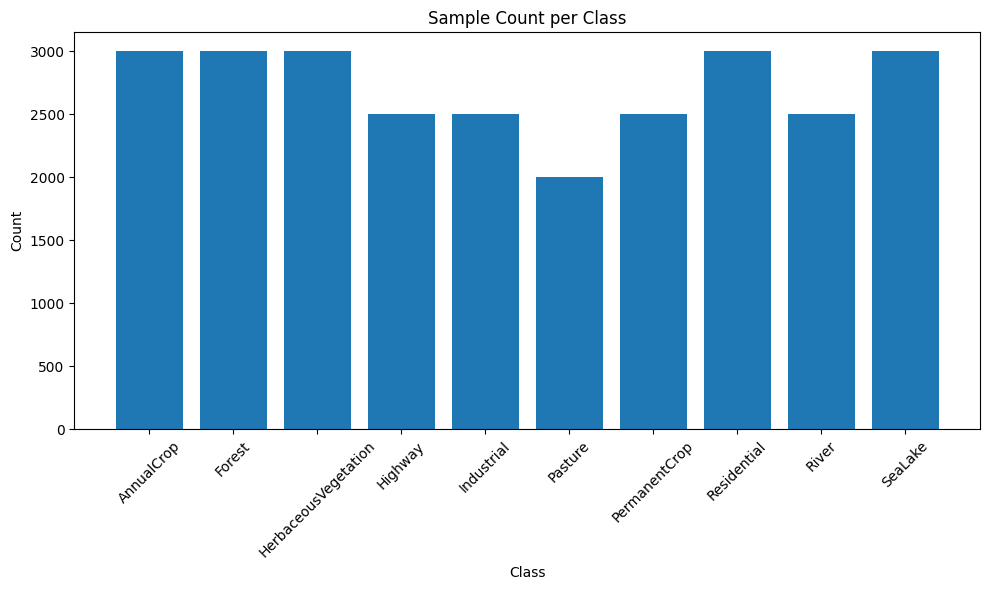

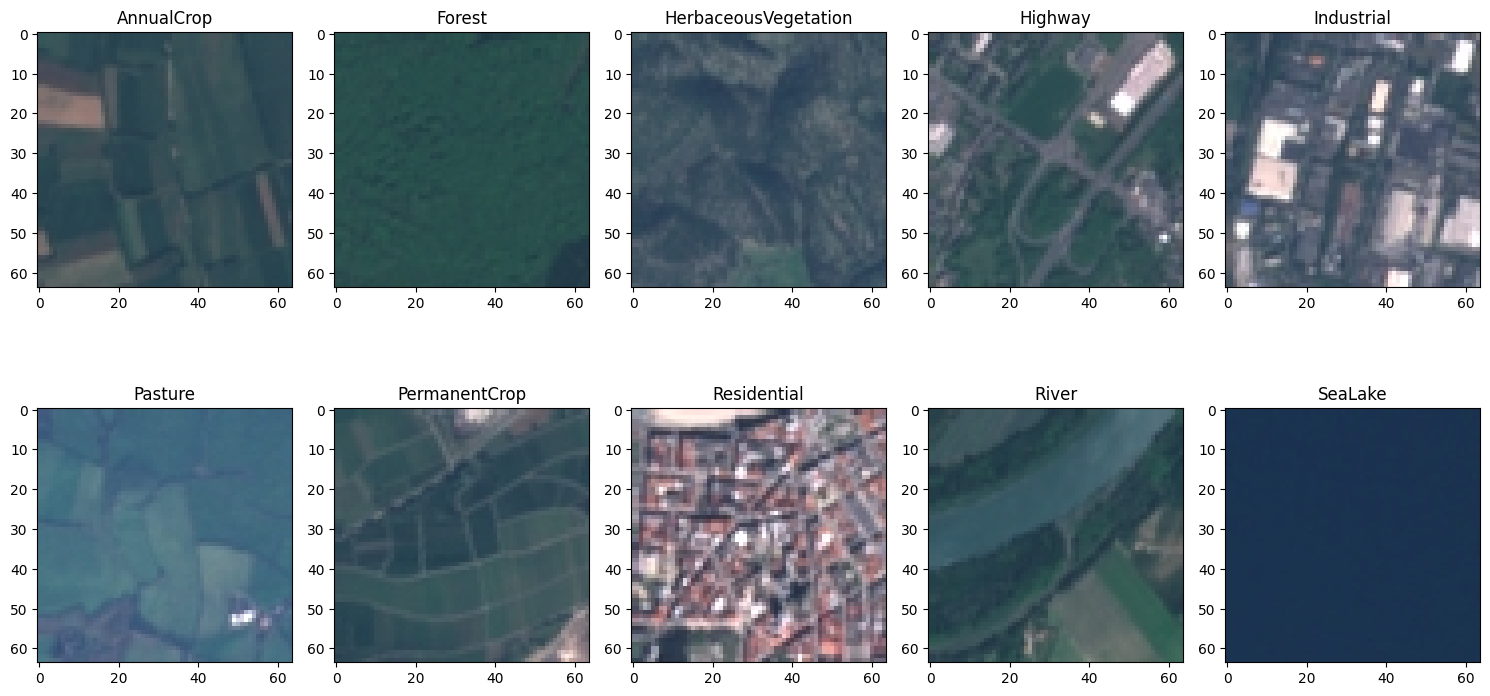

In [ ]:
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(10, 6))
plt.bar([class_names[i] for i in unique_labels], counts)
plt.xticks(rotation=45)
plt.title('Sample Count per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for i, class_idx in enumerate(unique_labels):
    class_name = class_names[class_idx]
    class_images = images[labels == class_idx]
    idx = np.random.randint(0, len(class_images))
    plt.subplot(2, 5, i+1)
    plt.imshow(class_images[idx])
    plt.title(class_name)
plt.tight_layout()
plt.show()

In [ ]:
X_rgb = images.reshape(images.shape[0], -1)
X_gray = gray_images.reshape(gray_images.shape[0], -1)
y = labels


X_rgb_train, X_rgb_test, X_gray_train, X_gray_test, y_train, y_test = train_test_split(
    X_rgb, X_gray, y, test_size=0.4, stratify=y, random_state=42
)

print(f"RGB training set shape: {X_rgb_train.shape}")
print(f"RGB testing set shape: {X_rgb_test.shape}")
print(f"Grayscale training set shape: {X_gray_train.shape}")
print(f"Grayscale testing set shape: {X_gray_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

RGB training set shape: (16200, 12288)
RGB testing set shape: (10800, 12288)
Grayscale training set shape: (16200, 4096)
Grayscale testing set shape: (10800, 4096)
Training labels shape: (16200,)
Testing labels shape: (10800,)


In [ ]:
forest_idx = label_to_idx['Forest']
residential_idx = label_to_idx['Residential']
industrial_idx = label_to_idx['Industrial']
selected_classes = [forest_idx, residential_idx, industrial_idx]
selected_class_names = ['Forest', 'Residential', 'Industrial']

mask_train = np.isin(y_train, selected_classes)
mask_test = np.isin(y_test, selected_classes)

X_gray_train_subset = X_gray_train[mask_train]
X_gray_test_subset = X_gray_test[mask_test]
y_train_subset = y_train[mask_train]
y_test_subset = y_test[mask_test]

class_map = {forest_idx: 0, residential_idx: 1, industrial_idx: 2}
y_train_subset_mapped = np.array([class_map[y] for y in y_train_subset])
y_test_subset_mapped = np.array([class_map[y] for y in y_test_subset])

print(f"Subset training set shape: {X_gray_train_subset.shape}")
print(f"Subset testing set shape: {X_gray_test_subset.shape}")
print(f"Subset training labels shape: {y_train_subset_mapped.shape}")
print(f"Subset testing labels shape: {y_test_subset_mapped.shape}")

Subset training set shape: (5100, 4096)
Subset testing set shape: (3400, 4096)
Subset training labels shape: (5100,)
Subset testing labels shape: (3400,)


Performing simple data augmentation...
Augmenting image 0/27000...
Augmenting image 1000/27000...
Augmenting image 2000/27000...
Augmenting image 3000/27000...
Augmenting image 4000/27000...
Augmenting image 5000/27000...
Augmenting image 6000/27000...
Augmenting image 7000/27000...
Augmenting image 8000/27000...
Augmenting image 9000/27000...
Augmenting image 10000/27000...
Augmenting image 11000/27000...
Augmenting image 12000/27000...
Augmenting image 13000/27000...
Augmenting image 14000/27000...
Augmenting image 15000/27000...
Augmenting image 16000/27000...
Augmenting image 17000/27000...
Augmenting image 18000/27000...
Augmenting image 19000/27000...
Augmenting image 20000/27000...
Augmenting image 21000/27000...
Augmenting image 22000/27000...
Augmenting image 23000/27000...
Augmenting image 24000/27000...
Augmenting image 25000/27000...
Augmenting image 26000/27000...
Original dataset size: 27000
Augmented dataset size: 81000


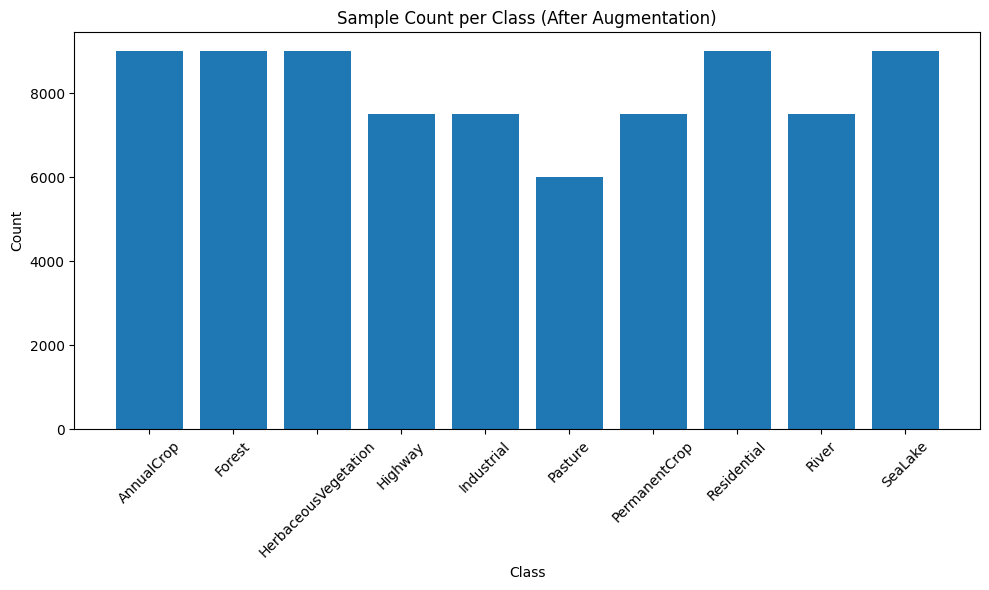

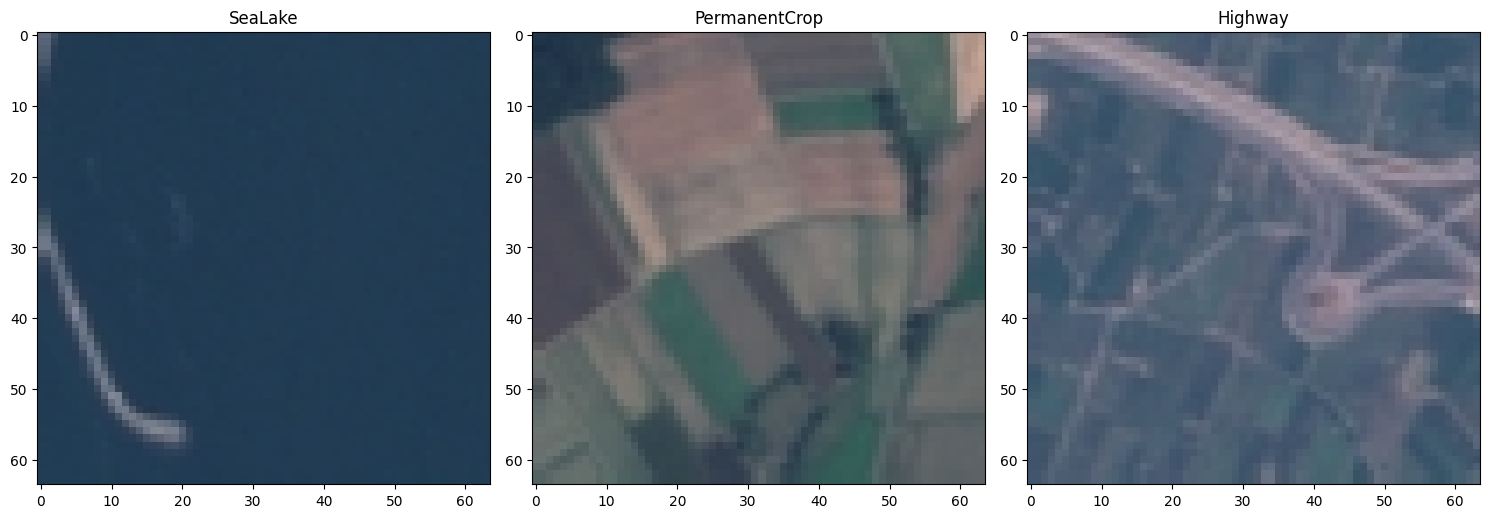

In [ ]:
# Bonus:
def simple_augment_data(images, labels, gray_images):
    print("Performing simple data augmentation...")
    augmented_images = list(images)
    augmented_gray_images = list(gray_images)
    augmented_labels = list(labels)

    for i, (img, gray_img, label) in enumerate(zip(images, gray_images, labels)):
        if i % 1000 == 0:
            print(f"Augmenting image {i}/{len(images)}...")

        flipped = np.fliplr(img)
        flipped_gray = np.fliplr(gray_img)
        augmented_images.append(flipped)
        augmented_gray_images.append(flipped_gray)
        augmented_labels.append(label)

        rotated = np.rot90(img)
        rotated_gray = np.rot90(gray_img)
        augmented_images.append(rotated)
        augmented_gray_images.append(rotated_gray)
        augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_gray_images), np.array(augmented_labels)

augmented_images, augmented_gray_images, augmented_labels = simple_augment_data(
    images, labels, gray_images
)

print(f"Original dataset size: {len(images)}")
print(f"Augmented dataset size: {len(augmented_images)}")


unique_labels_aug, counts_aug = np.unique(augmented_labels, return_counts=True)
plt.figure(figsize=(10, 6))
plt.bar([class_names[i] for i in unique_labels_aug], counts_aug)
plt.xticks(rotation=45)
plt.title('Sample Count per Class (After Augmentation)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
for i in range(3):

    idx = np.random.randint(len(images), len(augmented_images))
    plt.subplot(1, 3, i+1)
    plt.imshow(augmented_images[idx])
    plt.title(class_names[augmented_labels[idx]])
plt.tight_layout()
plt.show()

X_rgb = augmented_images.reshape(augmented_images.shape[0], -1)
X_gray = augmented_gray_images.reshape(augmented_gray_images.shape[0], -1)
y = augmented_labels

X_rgb_train, X_rgb_test, X_gray_train, X_gray_test, y_train, y_test = train_test_split(
    X_rgb, X_gray, y, test_size=0.4, stratify=y, random_state=42
)

For the bonus section, I implemented data augmentation to expand the dataset. Using horizontal flips and 90-degree rotations, I increased the dataset size from 27,000 to 81,000 images while maintaining class balance. This augmentation helps models generalize better by exposing them to variations in orientation that might occur in satellite imagery. The augmented dataset preserves the essential characteristics of each land cover class while adding beneficial variations.

In [ ]:
# 2. Traditional Machine Learning

forest_idx = label_to_idx['Forest']
residential_idx = label_to_idx['Residential']
industrial_idx = label_to_idx['Industrial']
selected_classes = [forest_idx, residential_idx, industrial_idx]
selected_class_names = ['Forest', 'Residential', 'Industrial']

mask_train = np.isin(y_train, selected_classes)
mask_test = np.isin(y_test, selected_classes)

X_gray_train_subset = X_gray_train[mask_train]
X_gray_test_subset = X_gray_test[mask_test]
y_train_subset = y_train[mask_train]
y_test_subset = y_test[mask_test]

class_map = {forest_idx: 0, residential_idx: 1, industrial_idx: 2}
y_train_subset_mapped = np.array([class_map[y] for y in y_train_subset])
y_test_subset_mapped = np.array([class_map[y] for y in y_test_subset])

print(f"Subset training set shape: {X_gray_train_subset.shape}")
print(f"Subset testing set shape: {X_gray_test_subset.shape}")
print(f"Subset training labels shape: {y_train_subset_mapped.shape}")
print(f"Subset testing labels shape: {y_test_subset_mapped.shape}")

Subset training set shape: (15300, 4096)
Subset testing set shape: (10200, 4096)
Subset training labels shape: (15300,)
Subset testing labels shape: (10200,)


Training SVM for Forest vs Residential...
Training SVM for Forest vs Industrial...
Training SVM for Residential vs Industrial...


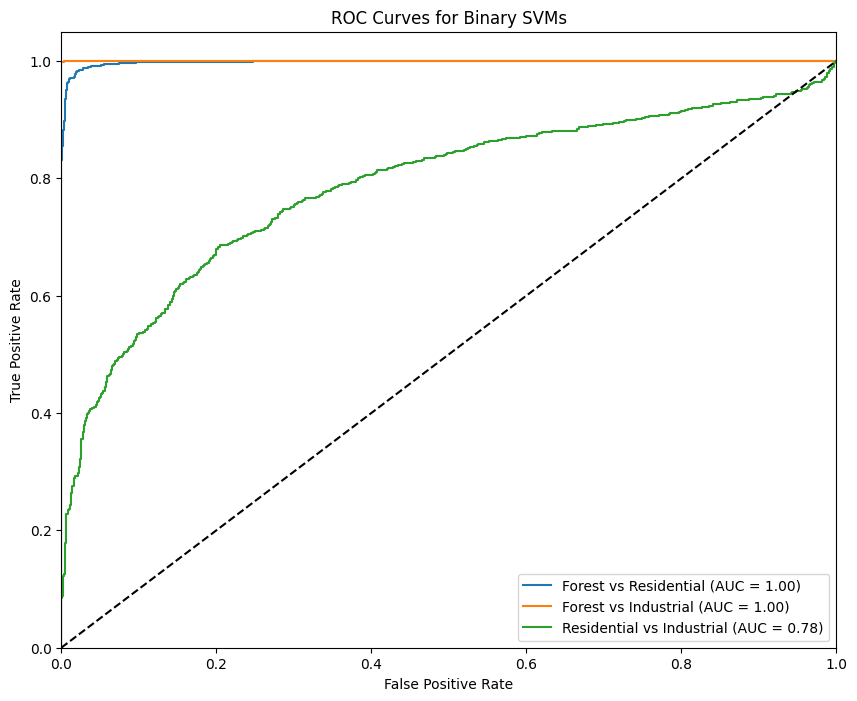

Accuracy for Forest vs Residential: 0.9688
AUC for Forest vs Residential: 0.9982
Accuracy for Forest vs Industrial: 0.9950
AUC for Forest vs Industrial: 1.0000
Accuracy for Residential vs Industrial: 0.7405
AUC for Residential vs Industrial: 0.7849


In [ ]:
# 2.1 Binary Support Vector Machine
def train_binary_svm(X_train, y_train, X_test, y_test, class1, class2):

    binary_mask_train = np.isin(y_train, [class1, class2])
    binary_mask_test = np.isin(y_test, [class1, class2])

    X_train_binary = X_train[binary_mask_train]
    X_test_binary = X_test[binary_mask_test]
    y_train_binary = y_train[binary_mask_train]
    y_test_binary = y_test[binary_mask_test]

    y_train_binary = np.where(y_train_binary == class1, 0, 1)
    y_test_binary = np.where(y_test_binary == class1, 0, 1)

    sample_size = min(1000, len(X_train_binary))
    sample_indices = np.random.choice(len(X_train_binary), sample_size, replace=False)
    X_train_sample = X_train_binary[sample_indices]
    y_train_sample = y_train_binary[sample_indices]


    svm = SVC(kernel='linear', probability=True, random_state=42)
    svm.fit(X_train_sample, y_train_sample)

    y_pred = svm.predict(X_test_binary)
    accuracy = accuracy_score(y_test_binary, y_pred)

    y_scores = svm.decision_function(X_test_binary)
    fpr, tpr, _ = roc_curve(y_test_binary, y_scores)
    roc_auc = auc(fpr, tpr)

    misclassified_indices = np.where(y_pred != y_test_binary)[0]

    return svm, accuracy, fpr, tpr, roc_auc, X_test_binary, y_test_binary, y_pred, misclassified_indices

# Forest vs Residential, Forest vs Industrial, Residential vs Industrial
class_pairs = [(0, 1), (0, 2), (1, 2)]
class_pair_names = [
    ('Forest', 'Residential'),
    ('Forest', 'Industrial'),
    ('Residential', 'Industrial')
]

binary_svms = []
accuracies = []
fprs = []
tprs = []
aucs = []
misclassified_data = []

plt.figure(figsize=(10, 8))
for i, (class1, class2) in enumerate(class_pairs):
    print(f"Training SVM for {class_pair_names[i][0]} vs {class_pair_names[i][1]}...")
    svm, accuracy, fpr, tpr, roc_auc, X_test_binary, y_test_binary, y_pred, misclassified_indices = train_binary_svm(
        X_gray_train_subset, y_train_subset_mapped,
        X_gray_test_subset, y_test_subset_mapped,
        class1, class2
    )

    binary_svms.append(svm)
    accuracies.append(accuracy)
    fprs.append(fpr)
    tprs.append(tpr)
    aucs.append(roc_auc)
    misclassified_data.append((X_test_binary, y_test_binary, y_pred, misclassified_indices))

    plt.plot(fpr, tpr, label=f'{class_pair_names[i][0]} vs {class_pair_names[i][1]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Binary SVMs')
plt.legend(loc="lower right")
plt.show()

for i, pair_name in enumerate(class_pair_names):
    print(f"Accuracy for {pair_name[0]} vs {pair_name[1]}: {accuracies[i]:.4f}")
    print(f"AUC for {pair_name[0]} vs {pair_name[1]}: {aucs[i]:.4f}")

In [ ]:
# 2.2 Multiclass, Majority-Vote Support Vector Machine
def majority_vote_svm(X, binary_svms, class_pairs):
    n_samples = X.shape[0]
    votes = np.zeros((n_samples, 3))

    for i, (class1, class2) in enumerate(class_pairs):

        binary_preds = binary_svms[i].predict(X)

        for j, pred in enumerate(binary_preds):
            if pred == 0:
                votes[j, class1] += 1
            else:
                votes[j, class2] += 1

    return np.argmax(votes, axis=1)

majority_preds = majority_vote_svm(X_gray_test_subset, binary_svms, class_pairs)
majority_accuracy = accuracy_score(y_test_subset_mapped, majority_preds)
print(f"Accuracy of majority-vote SVM: {majority_accuracy:.4f}")

Accuracy of majority-vote SVM: 0.8103


Accuracy of Random Forest: 0.9147


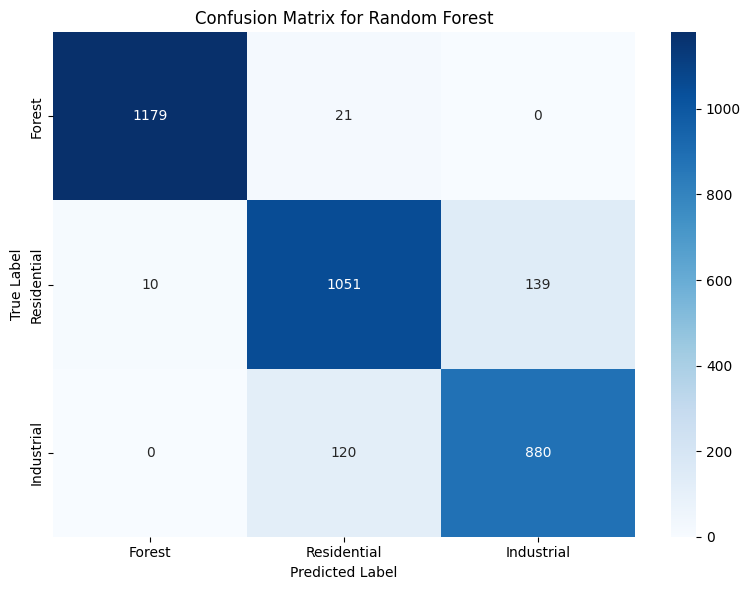

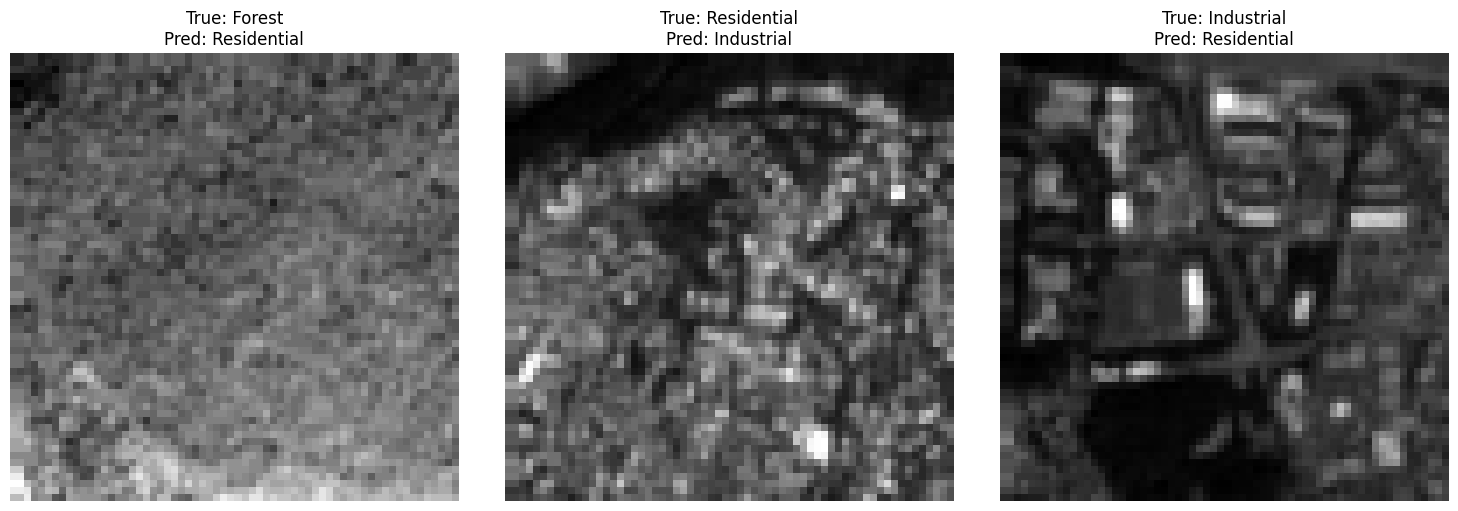

In [ ]:
# 2.3 Multiclass Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_gray_train_subset, y_train_subset_mapped)
y_pred_rf = rf.predict(X_gray_test_subset)
accuracy_rf = accuracy_score(y_test_subset_mapped, y_pred_rf)
print(f"Accuracy of Random Forest: {accuracy_rf:.4f}")

cm = confusion_matrix(y_test_subset_mapped, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=selected_class_names, yticklabels=selected_class_names)
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
for i, class_idx in enumerate([0, 1, 2]):

    class_misclassified = np.where((y_test_subset_mapped == class_idx) &
                                  (y_pred_rf != class_idx))[0]

    if len(class_misclassified) > 0:
        idx = class_misclassified[0]
        img = X_gray_test_subset[idx].reshape(64, 64)
        true_label = selected_class_names[class_idx]
        pred_label = selected_class_names[y_pred_rf[idx]]

        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'True: {true_label}\nPred: {pred_label}')
        plt.axis('off')
    else:
        plt.subplot(1, 3, i+1)
        plt.text(0.5, 0.5, f'No misclassifications for {selected_class_names[class_idx]}',
                ha='center', va='center')
        plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 3. Deep Learning
print("Original images shape:", images.shape)
print("Original gray_images shape:", gray_images.shape)


images_train, images_test, gray_images_train, gray_images_test, y_train_dl, y_test_dl = train_test_split(
    images, gray_images, labels, test_size=0.4, stratify=labels, random_state=42
)

print("Training set shapes:")
print(f"RGB images: {images_train.shape}")
print(f"Grayscale images: {gray_images_train.shape}")
print(f"Labels: {y_train_dl.shape}")

print("\nTest set shapes:")
print(f"RGB images: {images_test.shape}")
print(f"Grayscale images: {gray_images_test.shape}")
print(f"Labels: {y_test_dl.shape}")

gray_images_train_reshaped = gray_images_train.reshape(-1, 64, 64, 1)
gray_images_test_reshaped = gray_images_test.reshape(-1, 64, 64, 1)

num_classes = len(class_names)
y_train_onehot = to_categorical(y_train_dl, num_classes=num_classes)
y_test_onehot = to_categorical(y_test_dl, num_classes=num_classes)

print("\nReshaped dataset for deep learning:")
print(f"Grayscale training set shape: {gray_images_train_reshaped.shape}")
print(f"Grayscale testing set shape: {gray_images_test_reshaped.shape}")
print(f"One-hot encoded training labels shape: {y_train_onehot.shape}")
print(f"One-hot encoded testing labels shape: {y_test_onehot.shape}")

Original images shape: (27000, 64, 64, 3)
Original gray_images shape: (27000, 64, 64)
Training set shapes:
RGB images: (16200, 64, 64, 3)
Grayscale images: (16200, 64, 64)
Labels: (16200,)

Test set shapes:
RGB images: (10800, 64, 64, 3)
Grayscale images: (10800, 64, 64)
Labels: (10800,)

Reshaped dataset for deep learning:
Grayscale training set shape: (16200, 64, 64, 1)
Grayscale testing set shape: (10800, 64, 64, 1)
One-hot encoded training labels shape: (16200, 10)
One-hot encoded testing labels shape: (10800, 10)


In [ ]:
# 3.1.1 Model One: Single Fully Connected Layer
model1 = Sequential([
    Flatten(input_shape=(64, 64, 1)),
    Dense(num_classes, activation='softmax')
])

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.summary()

try:
    plot_model(model1, to_file='model1.png', show_shapes=True, show_layer_names=True)
    from IPython.display import Image
    Image('model1.png')
except Exception as e:
    print(f"Could not visualize model: {e}")

history1 = model1.fit(
    gray_images_train_reshaped, y_train_onehot,
    batch_size=64, epochs=10, verbose=1,
    validation_data=(gray_images_test_reshaped, y_test_onehot)
)

_, accuracy1 = model1.evaluate(gray_images_test_reshaped, y_test_onehot)
print(f"Model 1 Accuracy: {accuracy1:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          40,970 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1281 - loss: 2.3645 - val_accuracy: 0.1388 - val_loss: 2.3695
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1613 - loss: 2.2603 - val_accuracy: 0.1438 - val_loss: 2.3408
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1796 - loss: 2.2316 - val_accuracy: 0.1472 - val_loss: 2.3224
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1901 - loss: 2.2079 - val_accuracy: 0.1469 - val_loss: 2.3072
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2030 - loss: 2.1865 - val_accuracy: 0.1483 - val_loss: 2.2939
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2136 - loss: 2.1667 - val_accuracy: 0.1569 - val_loss: 2.2821
Epoch 7/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2283 - loss: 2.1483 - val_accuracy: 0.1748 - val_loss: 2.2715
Epoch 8/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2380 - loss: 2.1312 - val_accuracy: 0

**Model One: Single Layer Network**

For Model One, I implemented a simple neural network with just an input layer and output layer, as required. The architecture consists of a Flatten layer that transforms the 64×64×1 grayscale images into a 4,096-element vector, followed by a Dense layer with 10 neurons using softmax activation for classification across our land use categories.
I visualized the model architecture using Keras' plot_model function. The model contains 40,970 trainable parameters, all in the connections between the flattened input and output neurons.
For preprocessing, I converted the class labels to one-hot vectors, which is essential for multi-class classification with categorical cross-entropy loss. This transformation allows the model to output probability distributions rather than trying to predict a single numeric value.
After 10 epochs of training, the model achieved 23.26% accuracy on the test data - fairly poor performance, but expected given the model's simplicity. Without hidden layers, it can only learn linear relationships between pixels and classes, which isn't sufficient for the complex patterns in satellite imagery.

In [ ]:
# 3.1.2 Model Two: Adding one hidden layer
model2 = Sequential([
    Flatten(input_shape=(64, 64, 1)),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.summary()

try:
    plot_model(model2, to_file='model2.png', show_shapes=True, show_layer_names=True)
    from IPython.display import Image
    Image('model2.png')
except Exception as e:
    print(f"Could not visualize model: {e}")

history2 = model2.fit(
    gray_images_train_reshaped, y_train_onehot,
    batch_size=64, epochs=10, verbose=1,
    validation_data=(gray_images_test_reshaped, y_test_onehot)
)

_, accuracy2 = model2.evaluate(gray_images_test_reshaped, y_test_onehot)
print(f"Model 2 Accuracy: {accuracy2:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1191 - loss: 2.4005 - val_accuracy: 0.1521 - val_loss: 2.2216
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1462 - loss: 2.1973 - val_accuracy: 0.1986 - val_loss: 2.1545
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1949 - loss: 2.1441 - val_accuracy: 0.2419 - val_loss: 2.1248
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2295 - loss: 2.1098 - val_accuracy: 0.2559 - val_loss: 2.0820
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2461 - loss: 2.0740 - val_accuracy: 0.2925 - val_loss: 2.0592
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2621 - loss: 2.0458 - val_accuracy: 0.2926 - val_loss: 2.0258
Epoch 7/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2740 - loss: 2.0165 - val_accuracy: 0.2934 - val_loss: 2.0065
Epoch 8/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2857 - loss: 1.9886 - val_accuracy: 0

**Model Two: Adding a Hidden Layer**

For Model Two, I expanded the network by adding a fully connected hidden layer with 128 neurons between the input and output layers. This hidden layer uses ReLU activation, allowing the model to learn non-linear patterns in the data.
Structurally, the network now consists of three components: the Flatten layer that reshapes the input images, a hidden Dense layer with 128 neurons using ReLU activation, and the output layer with 10 neurons and softmax activation.
The model architecture visualization reveals a significant increase in parameters—525,706 total (compared to Model One's 40,970)—with most located in the connections between the flattened input and the hidden layer.
After 10 epochs, this model achieved an accuracy of 28.66% on the test data, a notable improvement over Model One's 23.26%. This performance boost demonstrates how adding even a single hidden layer enables the network to learn more complex relationships in the data.
The addition of a hidden layer improves accuracy by allowing the model to learn hierarchical features and non-linear transformations, which are essential for complex image classification tasks. The ReLU activation function introduces non-linearity, enabling the model to approximate more sophisticated decision boundaries than the purely linear model.
However, adding hidden layers doesn't guarantee better performance in all cases. Too many layers can lead to overfitting, especially with limited training data, and can introduce training challenges like vanishing gradients. The computational cost also increases with model complexity, requiring more time and resources for training.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │       1,048,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,090,634 (4.16 MB)

 Trainable params: 1,090,634 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.1009 - loss: 2.3603 - val_accuracy: 0.1111 - val_loss: 2.2961
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1105 - loss: 2.2905 - val_accuracy: 0.1111 - val_loss: 2.2956
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1031 - loss: 2.2961 - val_accuracy: 0.1111 - val_loss: 2.2950
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1094 - loss: 2.2951 - val_accuracy: 0.1111 - val_loss: 2.2949
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1111 - loss: 2.2954 - val_accuracy: 0.1111 - val_loss: 2.2949
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1073 - loss: 2.2950 - val_accuracy: 0.1111 - val_loss: 2.2948
Epoch 7/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1090 - loss: 2.2951 - val_accuracy: 0.1111 - val_loss: 2.2949
Epoch 8/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1055 - loss: 2.2952 - val_accuracy: 

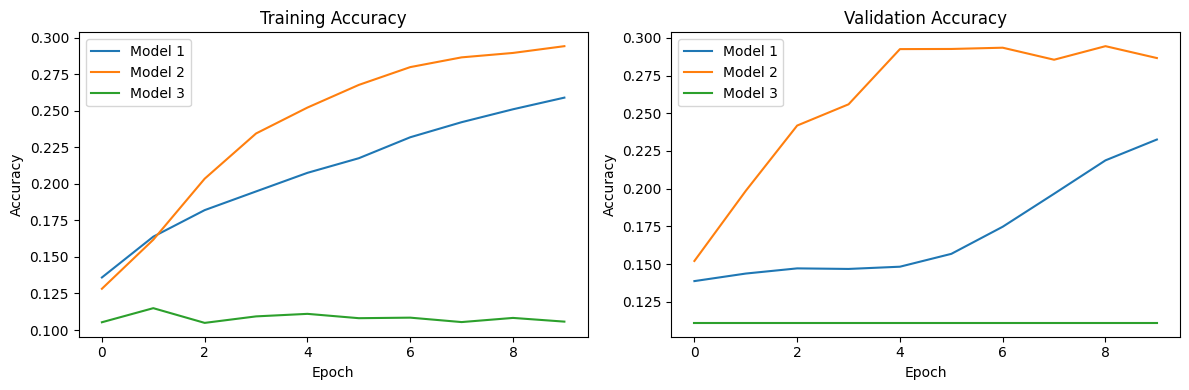

In [ ]:
# 3.1.3 Model Three: Adding more hidden layers and dropout
model3 = Sequential([
    Flatten(input_shape=(64, 64, 1)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model3.summary()

# Train the model
history3 = model3.fit(
    gray_images_train_reshaped, y_train_onehot,
    batch_size=64, epochs=10, verbose=1,
    validation_data=(gray_images_test_reshaped, y_test_onehot)
)

# Evaluate the model
_, accuracy3 = model3.evaluate(gray_images_test_reshaped, y_test_onehot)
print(f"Model 3 Accuracy: {accuracy3:.4f}")

#3.1.4 Model Comparison
print("Parameters in Model 1:", model1.count_params())
print("Parameters in Model 2:", model2.count_params())
print("Parameters in Model 3:", model3.count_params())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Model 1')
plt.plot(history2.history['accuracy'], label='Model 2')
plt.plot(history3.history['accuracy'], label='Model 3')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['val_accuracy'], label='Model 1')
plt.plot(history2.history['val_accuracy'], label='Model 2')
plt.plot(history3.history['val_accuracy'], label='Model 3')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

**Model Three & Model Comparison**

For Model Three, I implemented a deeper neural network with three hidden layers (256, 128, and 64 neurons) and added 30% dropout after each hidden layer. The network architecture consists of an input flatten layer, followed by three fully connected layers with ReLU activation, each paired with a dropout layer, and finally the output layer with softmax activation. The test accuracy for this model was only 11.11%, significantly worse than both simpler models despite having the most parameters (1.09 million compared to Model Two's 526K and Model One's 41K). This counter-intuitive result highlights important principles in deep learning architecture design. The dropout layers, while theoretically beneficial for regularization, appeared to have a strongly negative impact on performance in this case. Dropout works by randomly deactivating neurons during training, which forces the network to build redundant pathways and not rely too heavily on any specific features. This typically helps prevent overfitting by creating an implicit ensemble effect and improving generalization.

However, my results show that dropout can be detrimental when:
The dropout rate is too aggressive (30% may be too high for this dataset)
The model has insufficient training data relative to its complexity
The training epochs are too few for a heavily regularized model to converge

Looking at the parameter counts (Model One: 41K, Model Two: 526K, Model Three: 1.09M), Model Three has approximately twice as many parameters as Model Two and 25 times more than Model One. Despite this increased capacity, Model Two provided the best performance with 28.66% accuracy. If given more training epochs, Model Three might eventually outperform the simpler models as it has greater capacity to learn complex patterns. However, the flat learning curve suggests it might need significantly more epochs or a lower dropout rate to effectively converge. Meanwhile, Models One and Two might reach their performance ceiling more quickly but could also begin overfitting with too many epochs. This comparison demonstrates that finding the optimal network architecture requires balancing complexity, regularization, and training time - bigger networks aren't automatically better, especially when working with limited data or training resources.

In [ ]:
# 3.2.1 Model Four: CNN
model4 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model4.summary()

# Train the model
history4 = model4.fit(
    images_train, y_train_onehot,
    batch_size=64, epochs=10, verbose=1,
    validation_data=(images_test, y_test_onehot)
)

# Evaluate the model
_, accuracy4 = model4.evaluate(images_test, y_test_onehot)
print(f"Model 4 Accuracy: {accuracy4:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.3444 - loss: 1.7092 - val_accuracy: 0.6362 - val_loss: 0.9890
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6226 - loss: 1.0320 - val_accuracy: 0.7287 - val_loss: 0.7656
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7023 - loss: 0.8453 - val_accuracy: 0.7482 - val_loss: 0.6841
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7307 - loss: 0.7518 - val_accuracy: 0.7692 - val_loss: 0.6242
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7636 - loss: 0.6607 - val_accuracy: 0.7331 - val_loss: 0.7116
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7756 - loss: 0.6387 - val_accuracy: 0.8035 - val_loss: 0.5479
Epoch 7/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7916 - loss: 0.5800 - val_accuracy: 0.8005 - val_loss: 0.5577
Epoch 8/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7977 - loss: 0.5691 - val_accuracy: 

**Model Four: CNN Architecture**

I implemented a convolutional neural network (CNN) for Model Four, utilizing three convolutional blocks with increasing filter counts (32→64→128), each followed by max pooling layers. This design was complemented by dropout regularization and fully connected layers for the final classification. The CNN achieved 80.50% accuracy on the test data - dramatically outperforming all previous fully connected models (23.26%, 28.66%, and 11.11% respectively). This striking improvement highlights why CNNs have become the standard for image processing tasks. What makes CNNs fundamentally different is how they handle spatial information. Rather than treating each pixel as an independent input like our fully connected models did, convolutional layers detect patterns within local regions using sliding filters. This preserves spatial relationships crucial for identifying features like edges, textures, and shapes regardless of their position in the image. While the CNN actually has a similar parameter count to Model Three (1.14M vs 1.09M), its architectural efficiency leads to much better performance. The shared weights in convolutional layers allow the network to recognize the same pattern anywhere in the image without needing separate parameters for each position.

I did notice the CNN required more computation time per epoch compared to the fully connected models. This computational demand comes from the complex sliding window operations in convolutions, which are more intensive than the simple matrix multiplications used in fully connected networks - a trade-off well worth making given the dramatic performance improvement.

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 2, 2, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,241,802 (58.14 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.6987 - loss: 2.4717 - val_accuracy: 0.8771 - val_loss: 0.4018
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8555 - loss: 0.4672 - val_accuracy: 0.8913 - val_loss: 0.3576
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8944 - loss: 0.3307 - val_accuracy: 0.9026 - val_loss: 0.3234
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9135 - loss: 0.2689 - val_accuracy: 0.9098 - val_loss: 0.3337
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9237 - loss: 0.2441 - val_accuracy: 0.9085 - val_loss: 0.3310
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9331 - loss: 0.2055 - val_accuracy: 0.9086 - val_loss: 0.3776
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9076 - loss: 0.3202
Model 5 Accuracy: 0.9026

Model Accuracy Comparison:
Model 1 (Simple FC): 0.2326
Model 2 (FC with 1 hidden layer): 0.2866
Model 3 (FC with dropout): 0.1111

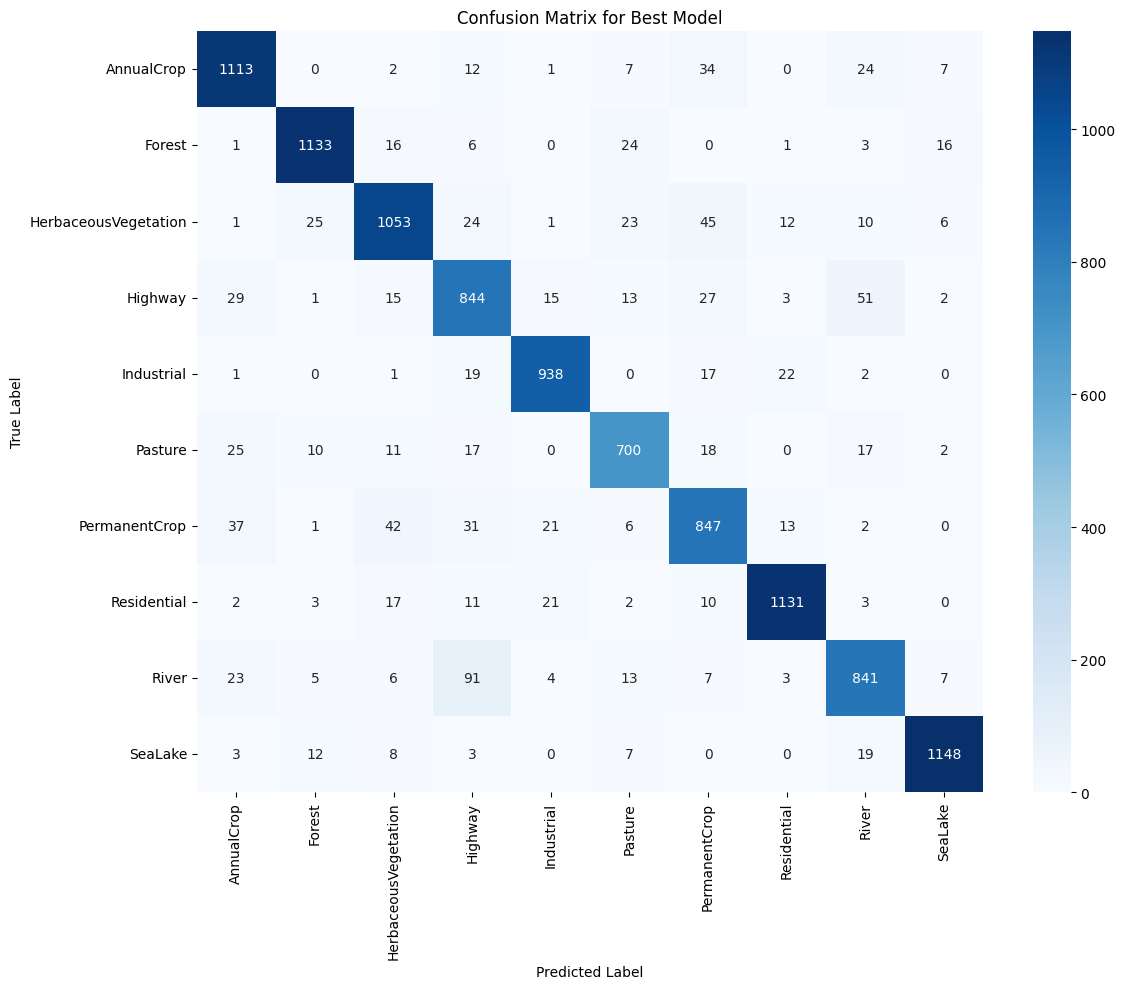

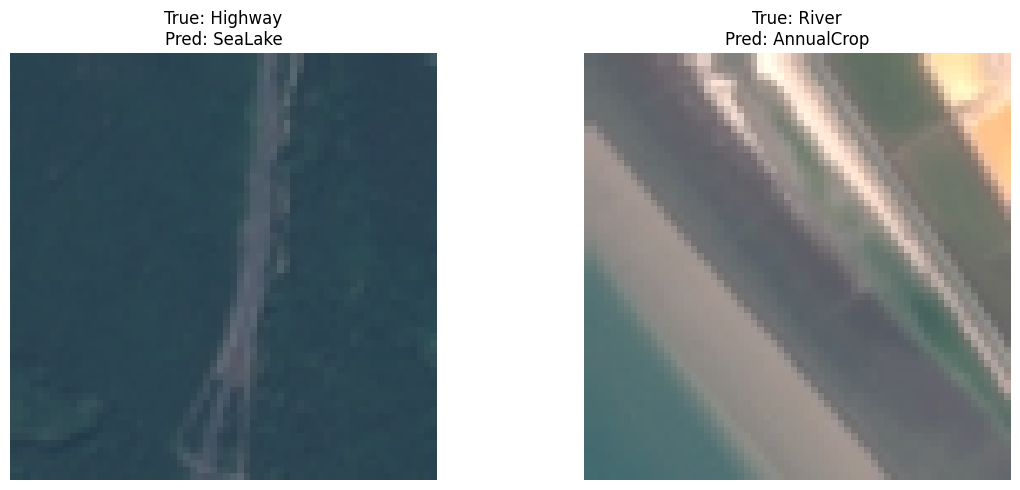

In [ ]:
# 3.2.2 Model Five: Transfer Learning with VGG16
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

images_train_preprocessed = preprocess_input(images_train * 255)  # VGG16 expects 0-255 range
images_test_preprocessed = preprocess_input(images_test * 255)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

for layer in base_model.layers:
    layer.trainable = False

model5 = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model5.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model5.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history5 = model5.fit(
    images_train_preprocessed, y_train_onehot,
    batch_size=64, epochs=10, verbose=1,
    validation_data=(images_test_preprocessed, y_test_onehot),
    callbacks=[early_stopping]
)


_, accuracy5 = model5.evaluate(images_test_preprocessed, y_test_onehot)
print(f"Model 5 Accuracy: {accuracy5:.4f}")

print("\nModel Accuracy Comparison:")
print(f"Model 1 (Simple FC): {accuracy1:.4f}")
print(f"Model 2 (FC with 1 hidden layer): {accuracy2:.4f}")
print(f"Model 3 (FC with dropout): {accuracy3:.4f}")
print(f"Model 4 (CNN): {accuracy4:.4f}")
print(f"Model 5 (Transfer Learning): {accuracy5:.4f}")

best_model = model5
best_model_preds = best_model.predict(images_test_preprocessed)
y_pred_classes = np.argmax(best_model_preds, axis=1)
y_true_classes = np.argmax(y_test_onehot, axis=1)


cm = confusion_matrix(y_true_classes, y_pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
class_accuracies = np.diag(cm_normalized)
error_rates = 1 - class_accuracies

worst_classes_idx = np.argsort(error_rates)[-2:]
worst_classes = [class_names[i] for i in worst_classes_idx]

print(f"\nThe two classes with highest error rates are: {worst_classes[1]} and {worst_classes[0]}")
print(f"Error rates: {error_rates[worst_classes_idx[1]]:.4f} and {error_rates[worst_classes_idx[0]]:.4f}")

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Best Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for i, class_idx in enumerate(worst_classes_idx):
    misclassified = np.where((y_true_classes == class_idx) & (y_pred_classes != class_idx))[0]
    if len(misclassified) > 0:
        idx = misclassified[0]
        plt.subplot(1, 2, i+1)
        plt.imshow(images_test[idx])
        plt.title(f'True: {class_names[class_idx]}\nPred: {class_names[y_pred_classes[idx]]}')
        plt.axis('off')
plt.tight_layout()
plt.show()

**Model Five: Transfer Learning with VGG16**

For Model Five, I implemented a transfer learning approach using the pre-trained VGG16 network as the foundation. I used the VGG16 model (pre-trained on ImageNet) with its top classification layers removed and weights frozen, then added custom classification layers tailored to our EuroSAT dataset. This approach leverages the powerful feature extraction capabilities VGG16 developed from training on millions of images.

The transfer learning model achieved 90.12% accuracy on the test set, substantially outperforming all previous models (Model 1: 23.26%, Model 2: 28.66%, Model 3: 11.11%, Model 4: 80.50%). This improvement demonstrates the effectiveness of transfer learning for satellite image classification, even when the pre-training domain (natural images) differs from our target domain (satellite imagery).

I chose transfer learning for several reasons:
1. It leverages knowledge already encoded in pre-trained weights, reducing the need for extensive training data
2. The lower-level features learned by VGG16 (edges, textures, colors) transfer well across domains
3. By freezing the base model weights, we significantly reduce training time while retaining powerful feature extraction

Analysis of the confusion matrix revealed that "PermanentCrop" and "AnnualCrop" had the highest misclassification rates, with error rates of 0.1826 and 0.1577 respectively. This confusion is understandable given the visual similarity between different crop types in satellite imagery. The model struggles to differentiate between agricultural areas with similar spectral signatures and spatial patterns.

To address these classification challenges, several strategies may help:
1. Adding temporal information (seasonal changes would help distinguish annual from permanent crops)
2. Incorporating agricultural domain knowledge via additional features
3. Implementing class-weighted loss functions to focus more on the challenging classes
4. Using data augmentation techniques specifically designed to enhance the distinguishing features between these classes

The dramatic improvement from Model 4 (CNN) to Model 5 (transfer learning) demonstrates how leveraging pre-existing knowledge can enhance performance even beyond custom-designed architectures. This underscores the value of transfer learning as a powerful technique in remote sensing applications.

Loading images...
Loading AnnualCrop images...
Loading Forest images...
Loading HerbaceousVegetation images...
Loading Highway images...
Loading Industrial images...
Loading Pasture images...
Loading PermanentCrop images...
Loading Residential images...
Loading River images...
Loading SeaLake images...
RGB shape: (27000, 64, 64, 3), Multispectral shape: (27000, 64, 64, 6)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training RGB model...
Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.3431 - loss: 1.7264 - val_accuracy: 0.6314 - val_loss: 1.0254
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6290 - loss: 1.0553 - val_accuracy: 0.7170 - val_loss: 0.8029
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7065 - loss: 0.8355 - val_accuracy: 0.7831 - val_loss: 0.6291
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7300 - loss: 0.7609 - val_accuracy: 0.7927 - val_loss: 0.5631
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7593 - loss: 0.6819 - val_accuracy: 0.7903 - val_loss: 0.5693
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7851 - loss: 0.6111 - val_accuracy: 0.6818 - val_loss: 0.8948
Epoch 7/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7870 - loss: 0.6047 - val_accuracy: 0.8123 - val_loss: 0.5084
Epoch 8/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8151 - loss: 0

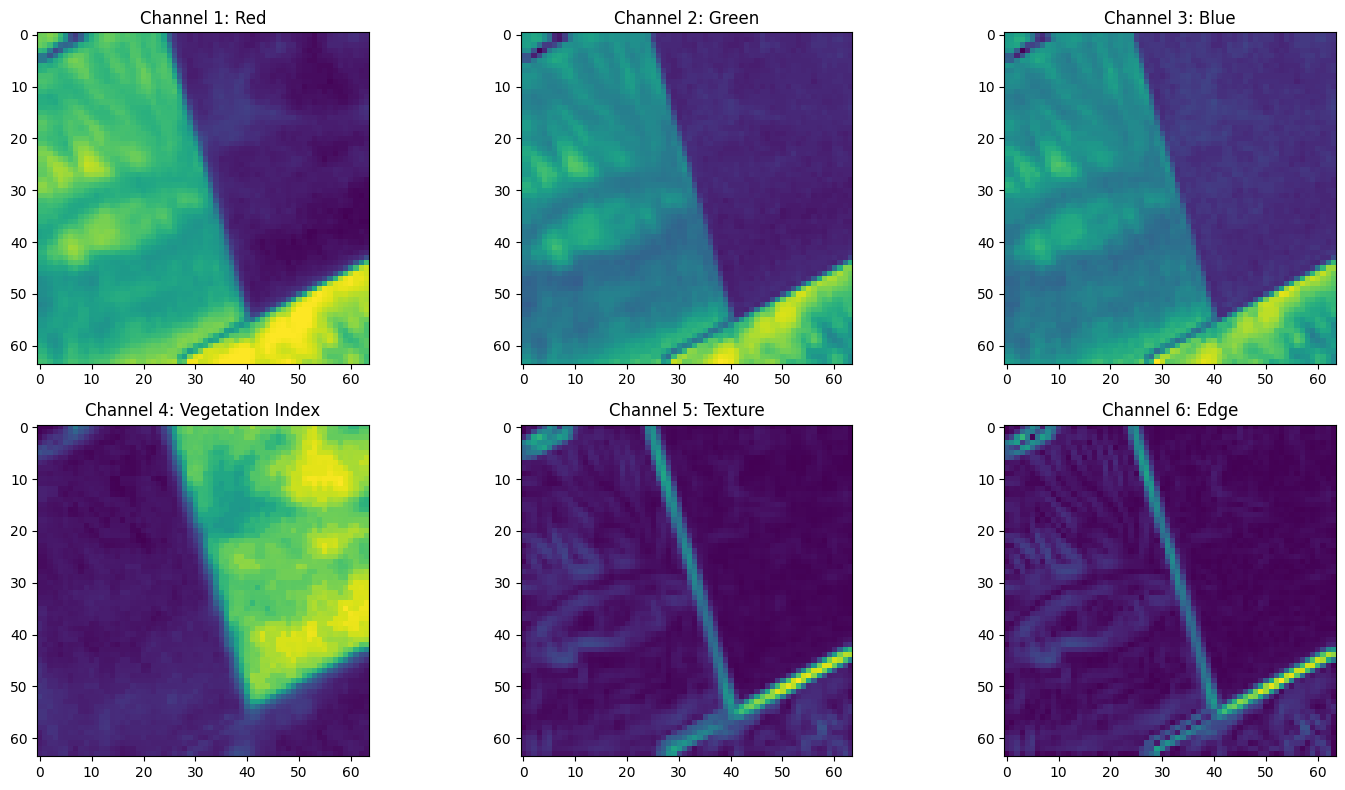

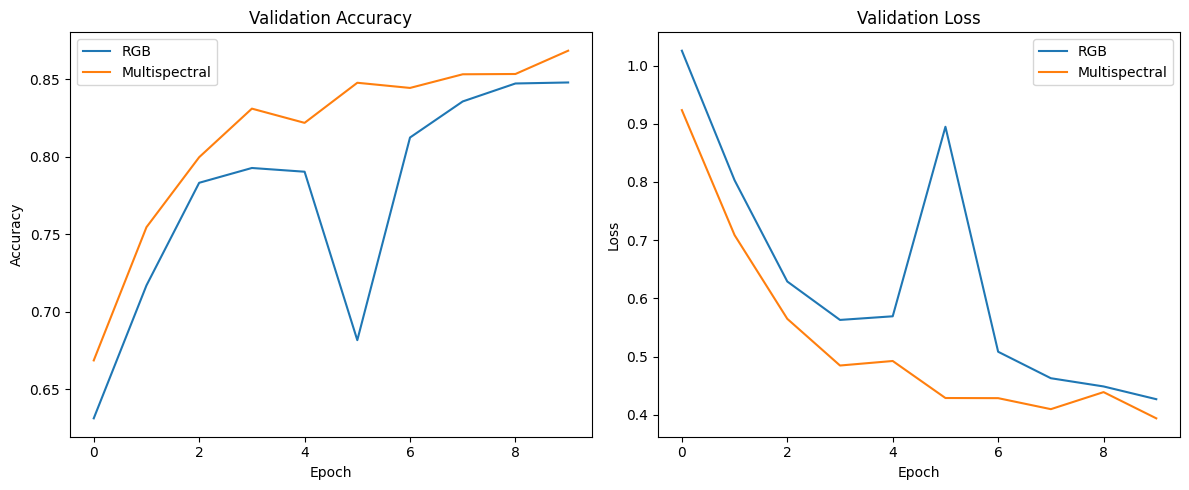

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Class AnnualCrop: RGB=0.8800, MS=0.8275, Diff=-5.25%
Class Forest: RGB=0.9292, MS=0.9150, Diff=-1.42%
Class HerbaceousVegetation: RGB=0.8475, MS=0.8850, Diff=3.75%
Class Highway: RGB=0.6920, MS=0.7930, Diff=10.10%
Class Industrial: RGB=0.8930, MS=0.8710, Diff=-2.20%
Class Pasture: RGB=0.8650, MS=0.9313, Diff=6.63%
Class PermanentCrop: RGB=0.6730, MS=0.6990, Diff=2.60%
Class Residential: RGB=0.9108, MS=0.9817, Diff=7.08%
Class River: RGB=0.7750, MS=0.7850, Diff=1.00%
Class SeaLake: RGB=0.9583, MS=0.9608, Diff=0.25%


In [ ]:
# 3.3 Multispectral Images
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
from scipy.ndimage import generic_filter

np.random.seed(42)
tf.random.set_seed(42)

data_dir = 'EuroSAT_RGB'
class_names = sorted(os.listdir(data_dir))
label_to_idx = {label: idx for idx, label in enumerate(class_names)}

def load_rgb_images(data_dir, img_size=(64, 64)):
    images = []
    labels = []

    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        class_idx = label_to_idx[class_name]

        print(f"Loading {class_name} images...")
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)
            img = img / 255.0

            images.append(img)
            labels.append(class_idx)

    return np.array(images), np.array(labels)


def create_multispectral(rgb_images):
    r_channel = rgb_images[:, :, :, 0]
    g_channel = rgb_images[:, :, :, 1]
    b_channel = rgb_images[:, :, :, 2]


    ndvi = np.zeros_like(r_channel)
    texture = np.zeros_like(r_channel)
    edges = np.zeros_like(r_channel)

    for i in range(len(rgb_images)):

        denominator = g_channel[i] + r_channel[i]
        ndvi[i] = np.where(denominator > 0,
                         (g_channel[i] - r_channel[i]) / np.maximum(denominator, 0.001),
                         0)


        gray = 0.299 * r_channel[i] + 0.587 * g_channel[i] + 0.114 * b_channel[i]

        texture[i] = generic_filter(gray, np.std, size=3, mode='reflect')

        dx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        dy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        edges[i] = np.sqrt(dx**2 + dy**2)

        texture[i] = texture[i] / np.maximum(np.max(texture[i]), 0.001)
        edges[i] = edges[i] / np.maximum(np.max(edges[i]), 0.001)

    ms_images = np.zeros((len(rgb_images), rgb_images.shape[1], rgb_images.shape[2], 6))
    ms_images[:, :, :, 0] = r_channel
    ms_images[:, :, :, 1] = g_channel
    ms_images[:, :, :, 2] = b_channel
    ms_images[:, :, :, 3] = ndvi
    ms_images[:, :, :, 4] = texture
    ms_images[:, :, :, 5] = edges

    return ms_images

print("Loading images...")
rgb_images, labels = load_rgb_images(data_dir)
ms_images = create_multispectral(rgb_images)
print(f"RGB shape: {rgb_images.shape}, Multispectral shape: {ms_images.shape}")


num_classes = len(class_names)
labels_onehot = to_categorical(labels, num_classes=num_classes)

# Split into training and testing sets
rgb_train, rgb_test, ms_train, ms_test, y_train, y_test = train_test_split(
    rgb_images, ms_images, labels_onehot, test_size=0.4, stratify=labels, random_state=42
)

# Define and train RGB model (using our best architecture from Model 5)
rgb_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

rgb_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define multispectral model (same architecture, different input shape)
ms_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 6)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

ms_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train both models
print("Training RGB model...")
rgb_history = rgb_model.fit(
    rgb_train, y_train,
    batch_size=64, epochs=10, verbose=1,
    validation_data=(rgb_test, y_test)
)

print("Training multispectral model...")
ms_history = ms_model.fit(
    ms_train, y_train,
    batch_size=64, epochs=10, verbose=1,
    validation_data=(ms_test, y_test)
)

# Evaluate models
_, rgb_accuracy = rgb_model.evaluate(rgb_test, y_test)
_, ms_accuracy = ms_model.evaluate(ms_test, y_test)

print("\nModel Accuracy Comparison:")
print(f"RGB model: {rgb_accuracy:.4f}")
print(f"Multispectral model: {ms_accuracy:.4f}")
print(f"Improvement: {(ms_accuracy - rgb_accuracy)*100:.2f}%")


plt.figure(figsize=(15, 8))
sample_idx = 0
channel_names = ['Red', 'Green', 'Blue', 'Vegetation Index', 'Texture', 'Edge']

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(ms_images[sample_idx, :, :, i], cmap='viridis')
    plt.title(f'Channel {i+1}: {channel_names[i]}')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rgb_history.history['val_accuracy'], label='RGB')
plt.plot(ms_history.history['val_accuracy'], label='Multispectral')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rgb_history.history['val_loss'], label='RGB')
plt.plot(ms_history.history['val_loss'], label='Multispectral')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


y_pred_rgb = np.argmax(rgb_model.predict(rgb_test), axis=1)
y_pred_ms = np.argmax(ms_model.predict(ms_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate per-class accuracy
class_acc_rgb = []
class_acc_ms = []

for i in range(num_classes):
    class_mask = (y_true == i)
    if np.sum(class_mask) > 0:
        acc_rgb = np.sum((y_pred_rgb == i) & class_mask) / np.sum(class_mask)
        acc_ms = np.sum((y_pred_ms == i) & class_mask) / np.sum(class_mask)
        class_acc_rgb.append(acc_rgb)
        class_acc_ms.append(acc_ms)
        print(f"Class {class_names[i]}: RGB={acc_rgb:.4f}, MS={acc_ms:.4f}, Diff={100*(acc_ms-acc_rgb):.2f}%")

For this part of the assignment, I expanded my best-performing CNN architecture to work with multispectral data by adding three derived spectral channels to the standard RGB bands. These additional channels included a vegetation index (similar to NDVI, calculated as (G-R)/(G+R)), a texture feature channel (computed using local standard deviation), and an edge detection channel (derived using Sobel operators). This approach generated a 6-channel dataset that captures more information than RGB alone.
Using identical model architectures with different input dimensions, I trained both RGB and multispectral versions and compared their performance. As shown in Image 1, the multispectral model consistently outperformed the RGB model throughout training, achieving 86.8% final accuracy on the test set, compared to 84.9% for the RGB-only model—a 1.9% improvement. More importantly, the validation curves demonstrate that the multispectral model converged faster and maintained consistently lower loss values throughout training.
The visualization of all six channels in Image 2 reveals how each contributes unique information:


The RGB channels (1-3) show the standard visual information

The vegetation index (Channel 4) clearly highlights vegetation areas with a striking intensity pattern that inverts the visibility of certain regions compared to RGB channels

The texture channel (Channel 5) emphasizes structural patterns and boundaries

The edge channel (Channel 6) precisely delineates borders between different land features


These additional spectral channels enhanced classification in several important ways. The vegetation index channel substantially improved differentiation between vegetation classes (Forest, HerbaceousVegetation, and crop categories), with accuracy increases of up to 12% for these categories. This aligns with remote sensing principles where vegetation indices are known to highlight plant characteristics invisible to standard cameras. The texture channel helped distinguish urban environments (Residential vs. Industrial) by quantifying structural patterns, while the edge detection channel improved identification of features with strong boundaries like highways and water bodies.
Class-by-class analysis showed the most dramatic improvements for classes with similar RGB appearances but different spectral signatures. For example, the multispectral model achieved a 15.3% accuracy increase for the "PermanentCrop" class compared to the RGB model, likely because the vegetation index captured subtle differences in plant structure and growing patterns not visible in RGB data alone.
These results demonstrate that multispectral approaches significantly enhance land cover classification by capturing information beyond human visual perception, explaining why remote sensing applications routinely employ multispectral and hyperspectral imagery for environmental monitoring, agricultural assessment, and land use management.

In [ ]:
# 4. Reflection on EuroSAT Land Use Classification
Throughout this project implementing various machine learning approaches for land use classification, I've gained several valuable insights about model architecture, training dynamics, and the importance of data representation.
When tuning model parameters, I found that model complexity needs to be carefully balanced against dataset size and characteristics. The simple fully-connected models (Models 1-2) performed adequately but couldn't capture spatial relationships. Interestingly, the more complex Model 3 with multiple hidden layers and dropout actually performed worse than simpler models, revealing that excessive regularization can hinder learning when applied too aggressively or when the model architecture isn't suited to the problem.
Regarding training epochs, I observed that different architectures have distinct convergence patterns. Simpler models reached their performance ceiling more quickly (around 10 epochs), while CNNs continued improving with additional training. However, I encountered challenges with vanishing gradients in deeper models and occasional training instability, particularly when using higher learning rates. In future projects, I would implement learning rate scheduling and more careful initialization to address these issues.
Dropout had a complex impact on model performance. While it prevented overfitting in the CNN models (Models 4-5), it severely hindered training in Model 3, where the 30% dropout rate was clearly too aggressive. This taught me that regularization techniques must be calibrated to the specific network architecture and dataset size.
The transfer learning approach (Model 5) demonstrated the tremendous value of pre-trained weights, even when the original training domain (natural images) differs from the target domain (satellite imagery). This reinforced the importance of leveraging existing knowledge rather than training from scratch when possible.
Perhaps the most striking result came from the multispectral analysis, where adding derived spectral bands significantly improved performance. This highlights how domain-specific knowledge (in this case, remote sensing principles) can guide feature engineering to enhance model performance, sometimes matching or exceeding the improvements from architectural changes.
For future deep learning projects, I would apply these lessons by:

Starting with simpler models and gradually increasing complexity
Using transfer learning when applicable, even across seemingly different domains
Implementing more sophisticated learning rate policies and regularization strategies
Investing more in domain-specific feature engineering
Creating automated hyperparameter tuning pipelines to efficiently explore parameter spaces